In [122]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ka66ledata/project-management-risk-raw")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'project-management-risk-raw' dataset.
Path to dataset files: /kaggle/input/project-management-risk-raw


In [123]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

In [124]:
data = pd.read_csv(r"/kaggle/input/project-management-risk-raw/project_risk_raw_dataset.csv")
data.head()

,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High


In [125]:
del data['Project_ID']

In [126]:
data.head()

,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,External_Dependencies_Count,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,2,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,0,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,5,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,2,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High


In [127]:
data.shape

(4000, 50)

In [128]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 50 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Project_Type                     4000 non-null   object 
 1   Team_Size                        4000 non-null   int64  
 2   Project_Budget_USD               4000 non-null   float64
 3   Estimated_Timeline_Months        4000 non-null   int64  
 4   Complexity_Score                 4000 non-null   float64
 5   Stakeholder_Count                4000 non-null   int64  
 6   Methodology_Used                 4000 non-null   object 
 7   Team_Experience_Level            4000 non-null   object 
 8   Past_Similar_Projects            4000 non-null   int64  
 9   External_Dependencies_Count      4000 non-null   int64  
 10  Change_Request_Frequency         4000 non-null   float64
 11  Project_Phase                    4000 non-null   object 
 12  Requirement_Stabilit

In [129]:
data.duplicated().sum()

np.int64(0)

In [130]:
data.nunique()

,0
Project_Type,6
Team_Size,49
Project_Budget_USD,4000
Estimated_Timeline_Months,35
Complexity_Score,796
Stakeholder_Count,27
Methodology_Used,5
Team_Experience_Level,4
Past_Similar_Projects,11
External_Dependencies_Count,8


Risk_Level
Medium      0.3490
High        0.2590
Low         0.2015
Critical    0.1905
Name: proportion, dtype: float64


<Axes: xlabel='Risk_Level', ylabel='count'>

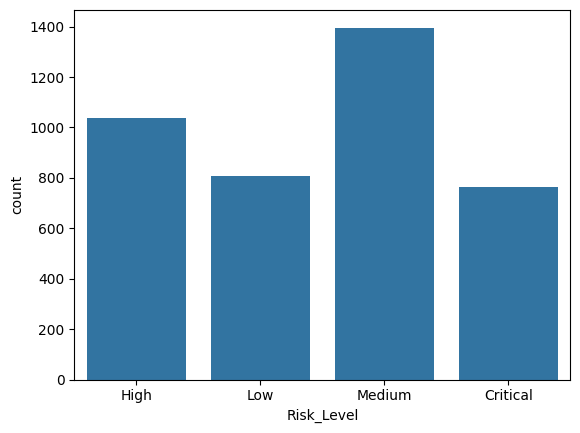

In [131]:
print(data["Risk_Level"].value_counts(normalize = True))
sns.countplot(x="Risk_Level",data = data)

In [132]:
data.isnull().sum()

,0
Project_Type,0
Team_Size,0
Project_Budget_USD,0
Estimated_Timeline_Months,0
Complexity_Score,0
Stakeholder_Count,0
Methodology_Used,0
Team_Experience_Level,0
Past_Similar_Projects,0
External_Dependencies_Count,0


In [133]:
del data['Tech_Environment_Stability']


In [134]:
data['Risk_Management_Maturity'].fillna(data['Risk_Management_Maturity'].mode()[0], inplace=True)

/tmp/ipython-input-3814774810.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Risk_Management_Maturity'].fillna(data['Risk_Management_Maturity'].mode()[0], inplace=True)


In [135]:
data['Change_Control_Maturity'].fillna(data['Change_Control_Maturity'].mode()[0], inplace=True)

/tmp/ipython-input-3637329723.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Change_Control_Maturity'].fillna(data['Change_Control_Maturity'].mode()[0], inplace=True)


In [136]:
data.isnull().sum()

,0
Project_Type,0
Team_Size,0
Project_Budget_USD,0
Estimated_Timeline_Months,0
Complexity_Score,0
Stakeholder_Count,0
Methodology_Used,0
Team_Experience_Level,0
Past_Similar_Projects,0
External_Dependencies_Count,0


In [137]:
data.head()

,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,External_Dependencies_Count,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,2,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,0,...,Stable,Regular,Formal,Basic,Hybrid,Good,5,1,1.0,Medium
3,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,5,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,2,...,Moderate,Occasional,Basic,Basic,Partially Colocated,Basic,9,6,1.0,High


In [138]:
data.isnull().sum()

,0
Project_Type,0
Team_Size,0
Project_Budget_USD,0
Estimated_Timeline_Months,0
Complexity_Score,0
Stakeholder_Count,0
Methodology_Used,0
Team_Experience_Level,0
Past_Similar_Projects,0
External_Dependencies_Count,0


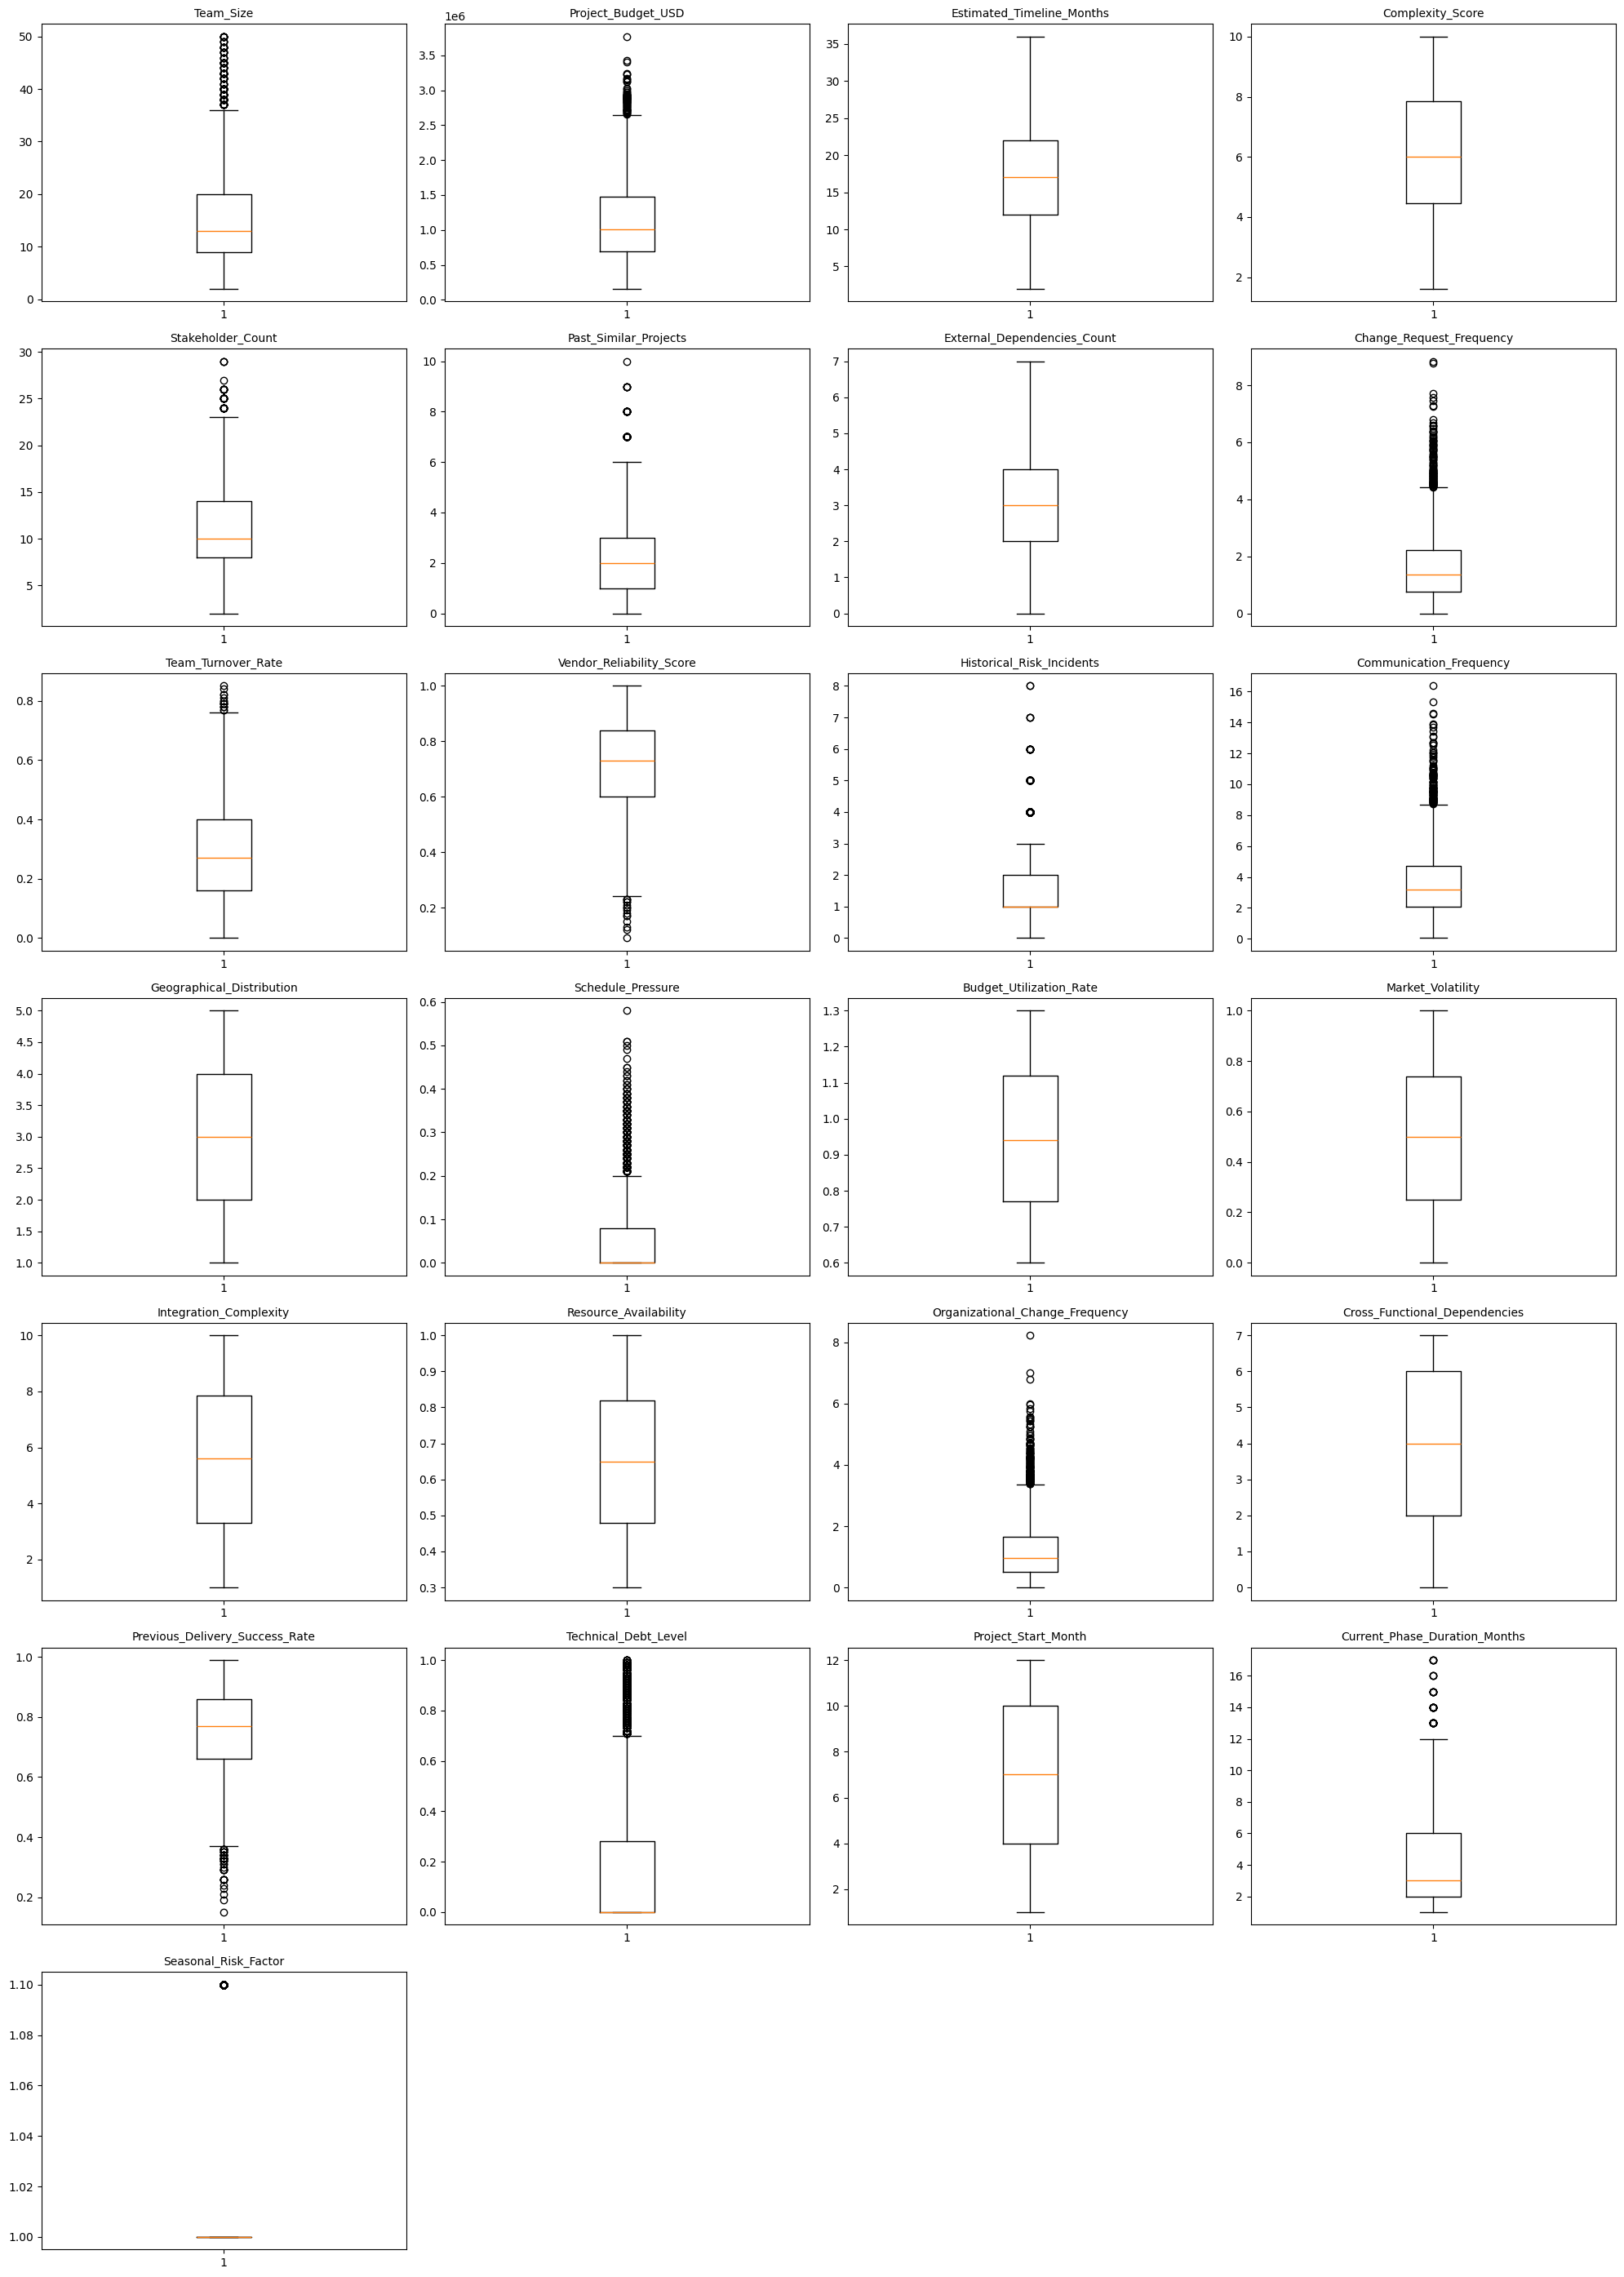

In [139]:
import matplotlib.pyplot as plt
import math

numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = len(numerical_cols)
cols_per_row = 4  # عدد boxplots في كل صف
rows = math.ceil(num_cols / cols_per_row)

plt.figure(figsize=(cols_per_row*5, rows*4))  # تعديل حجم الشكل حسب الأعمدة
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    plt.boxplot(data[col].dropna())
    plt.title(col, fontsize=10)
plt.tight_layout()
plt.show()


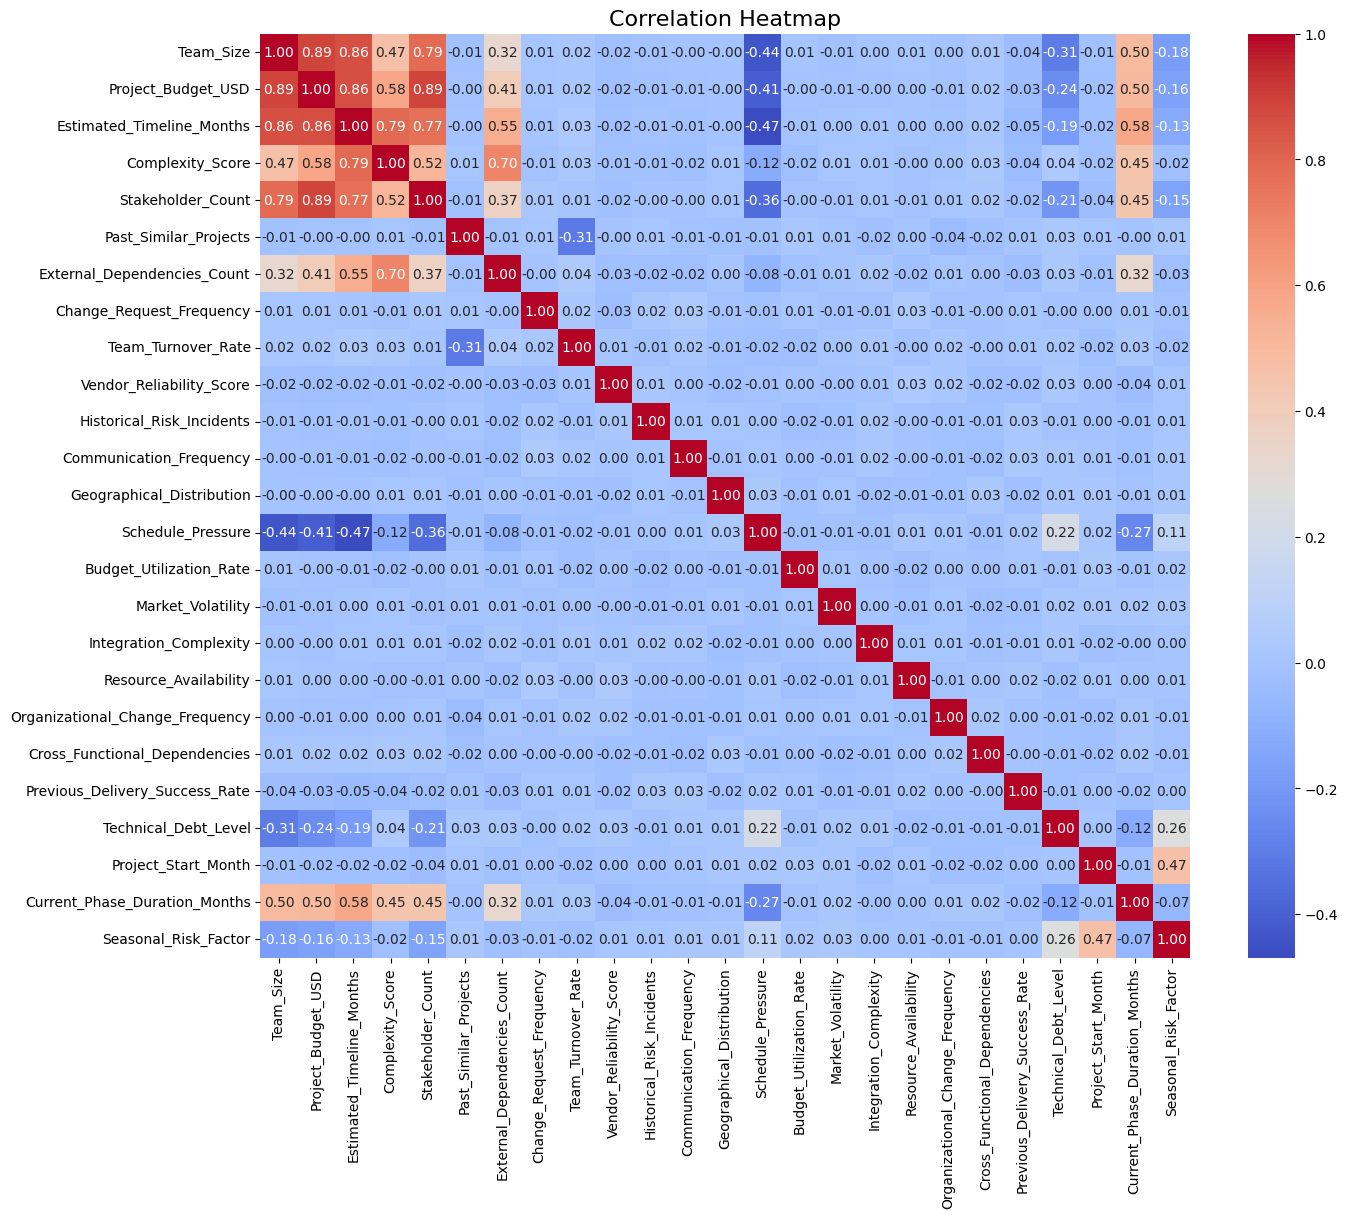

In [140]:


numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = data[numerical_cols].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()


In [141]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder ,LabelEncoder
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = data.drop("Risk_Level", axis=1)
y = data["Risk_Level"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=42, stratify=y)




In [142]:
nominal_cols = [
    "Requirement_Stability",
    "Funding_Source",
    "Contract_Type",
    "Team_Colocation",
    "Project_Type",
    "Methodology_Used",
    "Project_Manager_Experience",
]

ordinal_cols = [
    "Project_Phase",
    "Regulatory_Compliance_Level",
    "Technology_Familiarity",
    "Stakeholder_Engagement_Level",
    "Executive_Sponsorship",
    "Priority_Level",
    "Org_Process_Maturity",
    "Data_Security_Requirements",
    "Key_Stakeholder_Availability",
    "Resource_Contention_Level",
    "Industry_Volatility",
    "Client_Experience_Level",
    "Change_Control_Maturity",
    "Risk_Management_Maturity",
    "Documentation_Quality",
    "Team_Experience_Level"
]

ordinal_categories = [

    ["Initiation", "Planning", "Execution", "Monitoring", "Closure"],
    ["Low", "Medium", "High", "Critical"],
    ["New", "Familiar", "Expert"],
    ["Poor", "Low", "Medium", "High", "Excellent"],
    ["Weak", "Moderate", "Strong"],
    ["Low", "Medium", "High", "Critical"],
    ["Ad-hoc", "Defined", "Managed", "Optimizing"],
    ["Low", "Medium", "High", "Strict"],
    ["Poor", "Limited", "Moderate", "Good", "Excellent"],
    ["Low", "Medium", "High"],
    ["Stable", "Moderate", "High", "Extreme"],
    ["First-time", "Occasional", "Regular", "Strategic"],
    ["None", "Basic", "Formal", "Advanced"],
    ["None", "Basic", "Formal", "Advanced"],
    ["Poor", "Basic", "Good", "Excellent"],

    ["Junior", "Mixed", "Senior", "Expert"]
]




preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"), nominal_cols),
        ("ordinal", OrdinalEncoder(categories=ordinal_categories), ordinal_cols)
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded  = preprocessor.transform(X_test)


In [143]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [144]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),

    ('model', XGBClassifier(
        objective='multi:softprob',
        num_class=4,
        eval_metric='mlogloss',
        n_estimators=900,
        max_depth=4,
        learning_rate=0.02,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        gamma=0.2,
        reg_lambda=3,
        reg_alpha=1,
        random_state=42
    ))
])


In [145]:
pipeline_xgb.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Requirement_Stability',
                                                   'Funding_Source',
                                                   'Contract_Type',
                                                   'Team_Colocation',
                                                   'Project_Type',
                                                   'Methodology_Used',
                                                   'Project_Manager_Experience']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Initiation',
                                                                              'Planni...
                               feature_types=None, feature_weights=None,
                               gamma=0.2, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.02,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=900,
                               n_jobs=None, num_class=4, ...))])

In [146]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
y_pred = pipeline_xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.62125
              precision    recall  f1-score   support

           0       0.73      0.56      0.63       153
           1       0.51      0.48      0.49       207
           2       0.77      0.67      0.72       161
           3       0.59      0.73      0.65       279

    accuracy                           0.62       800
   macro avg       0.65      0.61      0.62       800
weighted avg       0.63      0.62      0.62       800



In [147]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline_xgb, X, le.fit_transform(y), cv=cv, scoring="accuracy")
print("CV Accuracy:", scores.mean())
print("Std:", scores.std())

CV Accuracy: 0.6399999999999999
Std: 0.015227442332841071


In [148]:
pip install catboost

In [156]:
from catboost import CatBoostClassifier
cat_model = CatBoostClassifier(
    iterations=600,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',
    verbose=0,
    random_seed=42
)

cat_model.fit(X_train, y_train, cat_features=nominal_cols + ordinal_cols)

y_pred = cat_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.6875

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.62      0.71       153
           1       0.60      0.59      0.60       207
           2       0.80      0.70      0.75       161
           3       0.65      0.78      0.71       279

    accuracy                           0.69       800
   macro avg       0.72      0.68      0.69       800
weighted avg       0.70      0.69      0.69       800



In [157]:
cat_model.save_model("catboost_model.cbm")

In [165]:
test_data = X_test.copy()
test_data['target'] = y_test
test_data.to_csv("test_data.csv", index=False)
